In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# select demand for victoria and sort in order of date
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/master_data.csv")
demand.sort()

df_list = [pd.read_csv(f) for f in demand]
if df_list:
    print("CSV files loaded")
else:
    print("No CSV files were loaded.")

# Ensure all data can be loaded
# print(df_list)

CSV files loaded


## Serval Graphs

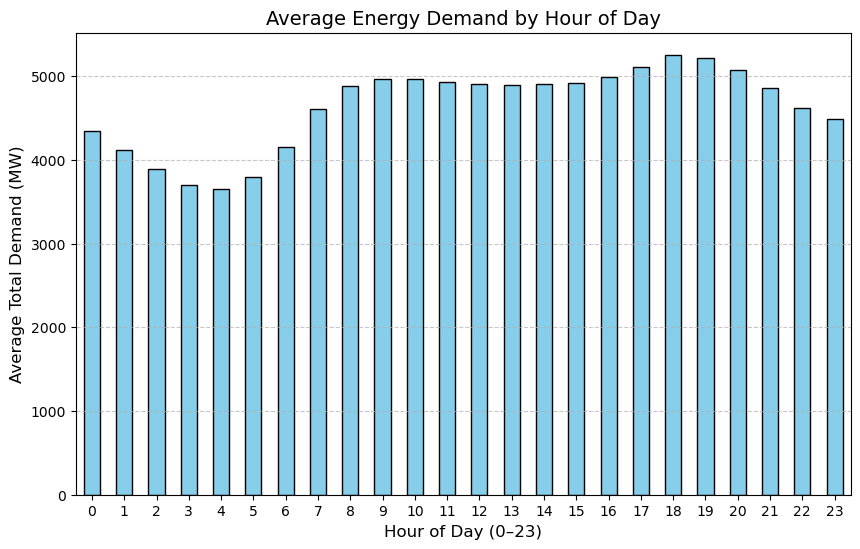

In [12]:
df = pd.concat(df_list, ignore_index=True)


# Parse datetime column
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y/%m/%d %H:%M")

# Extract hour of the day
df['Hour'] = df['Datetime'].dt.hour

# Compute average demand per hour
avg_demand = df.groupby('Hour')['Total Demand'].mean()

# Plot bar graph
plt.figure(figsize=(10,6))
avg_demand.plot(kind='bar', color="skyblue", edgecolor="black")

plt.title("Average Energy Demand by Hour of Day", fontsize=14)
plt.xlabel("Hour of Day (0–23)", fontsize=12)
plt.ylabel("Average Total Demand (MW)", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

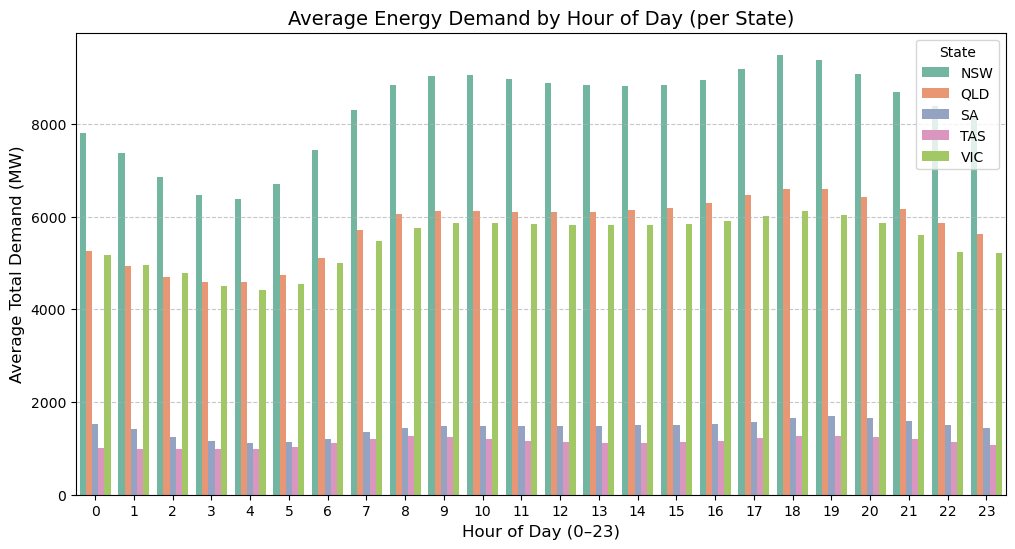

In [6]:
# Compute average demand per hour per state
avg_demand = df.groupby(['State', 'Hour'])['Total Demand'].mean().reset_index()

# Plot grouped bar chart
plt.figure(figsize=(12,6))
sns.barplot(
    data=avg_demand,
    x='Hour',
    y='Total Demand',
    hue='State',
    palette='Set2'
)

plt.title("Average Energy Demand by Hour of Day (per State)", fontsize=14)
plt.xlabel("Hour of Day (0–23)", fontsize=12)
plt.ylabel("Average Total Demand (MW)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="State")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

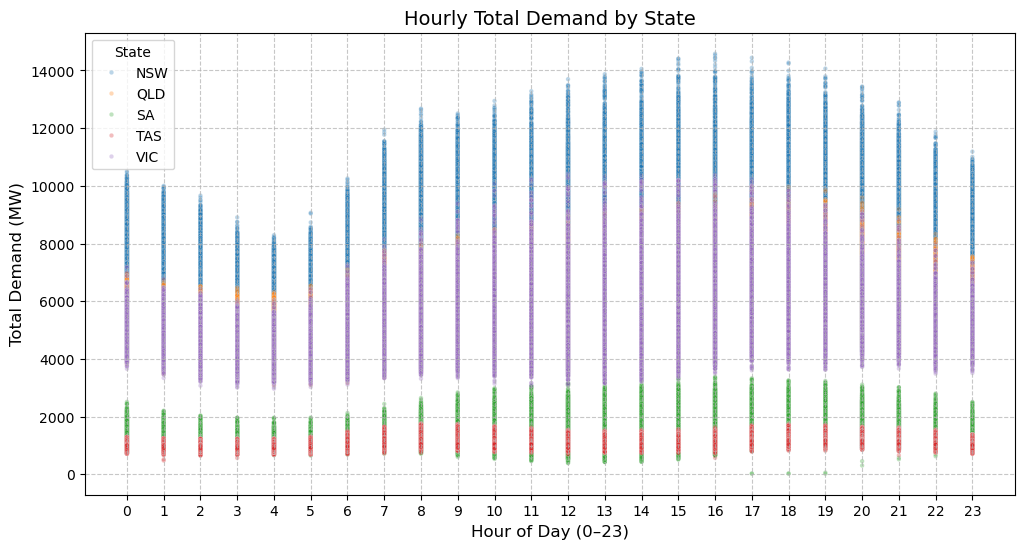

In [16]:
# Filter year range 2000–2019
# df = df[(df['Datetime'].dt.year >= 2000) & (df['Datetime'].dt.year <= 2019)]

# Extract hour of day
df['Hour'] = df['Datetime'].dt.hour

# Scatter plot
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df,
    x='Hour',
    y='Total Demand',
    hue='State',
    alpha=0.3,    # transparency to avoid overplotting
    s=10          # point size
)

plt.title("Hourly Total Demand by State", fontsize=14)
plt.xlabel("Hour of Day (0–23)", fontsize=12)
plt.ylabel("Total Demand (MW)", fontsize=12)
plt.xticks(range(0,24))
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="State")
plt.show()


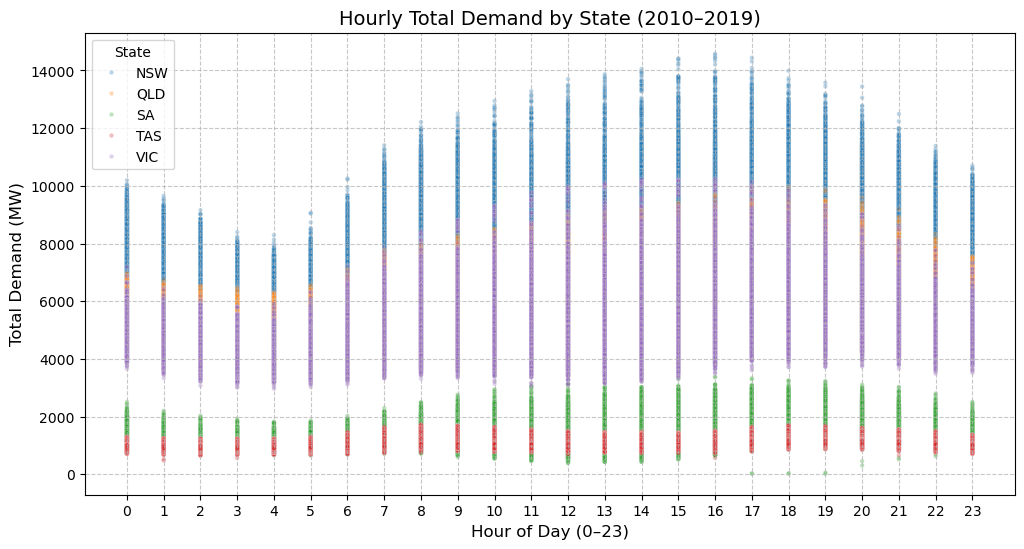

In [8]:
# Filter year range 2000–2019
df = df[(df['Datetime'].dt.year >= 2010) & (df['Datetime'].dt.year <= 2019)]

# Extract hour of day
df['Hour'] = df['Datetime'].dt.hour

# Scatter plot
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df,
    x='Hour',
    y='Total Demand',
    hue='State',
    alpha=0.3,    # transparency to avoid overplotting
    s=10          # point size
)

plt.title("Hourly Total Demand by State (2010–2019)", fontsize=14)
plt.xlabel("Hour of Day (0–23)", fontsize=12)
plt.ylabel("Total Demand (MW)", fontsize=12)
plt.xticks(range(0,24))
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="State")
plt.show()


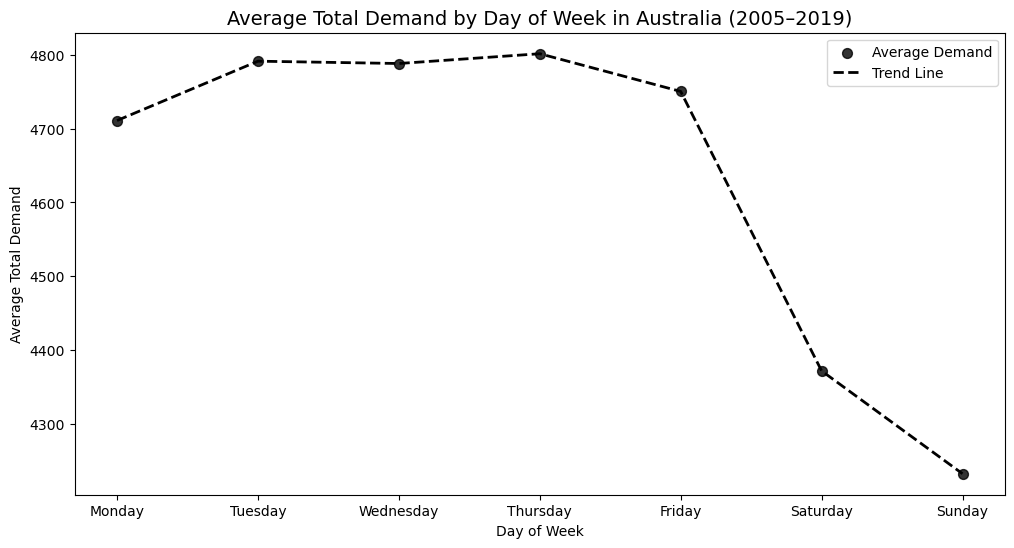

Average Total Demand by Day of Week:
Day
Monday       4710.93
Tuesday      4791.32
Wednesday    4788.16
Thursday     4801.42
Friday       4750.32
Saturday     4371.80
Sunday       4232.48
Name: Total Demand, dtype: float64


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

df['Day'] = df['Datetime'].dt.day_name()

# Define the correct order of days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Calculate average total demand for each day
average_demand_by_day = df.groupby('Day')['Total Demand'].mean()

# Reindex to ensure days are ordered from Monday to Sunday
average_demand_by_day = average_demand_by_day.reindex(day_order)

# Create scatter plot with a connecting line
plt.figure(figsize=(12, 6))
plt.scatter(average_demand_by_day.index, average_demand_by_day.values, 
            color='black', s=50, alpha=0.8, label='Average Demand')
plt.plot(average_demand_by_day.index, average_demand_by_day.values, 
         color='black', linewidth=2, linestyle='--', label='Trend Line')

# Update title and labels
plt.title("Average Total Demand by Day of Week in Australia (2005–2019)", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Average Total Demand")
plt.legend()

# Show plot
plt.show()

# Print the averages
print("Average Total Demand by Day of Week:")
print(average_demand_by_day.round(2))
